In [27]:
import wandb
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

wandb.login()
api = wandb.Api()

# === CONFIGURATION ===
DATASET = "totalseg_mri"  # Options: "totalseg_ct", "totalseg_mri", "medsegbench"

# Filter options (applied before analysis)
EXCLUDE_VERTEBRAE = True  # Set to True to exclude vertebrae from analysis
EXCLUDE_RIBS = False       # Set to True to exclude ribs from analysis
EXCLUDE_CUSTOM = []        # Add custom label patterns to exclude, e.g. ['kidney_cyst']
EXCLUDE_RESOLUTIONS = []   # Resolutions to exclude, e.g. [128, 512] to keep only 256

dataset_configs = {
    "medsegbench": {"patch_icl": "l8huu3nw", "universeg": "gwyrmzg2"},
    "totalseg_mri": {"patch_icl": "it2791g9", "universeg": "heb3m2pl"},
    "totalseg_ct": {"patch_icl": "eqjm8p9c", "universeg": "w3vfqmn2"},
}

runs = {k: {"wandb_name": v} for k, v in dataset_configs[DATASET].items()}
print(f"Dataset: {DATASET}")
print(f"Filters: vertebrae={EXCLUDE_VERTEBRAE}, ribs={EXCLUDE_RIBS}, custom={EXCLUDE_CUSTOM}, resolutions={EXCLUDE_RESOLUTIONS}")

Dataset: totalseg_mri
Filters: vertebrae=True, ribs=False, custom=[], resolutions=[]


In [28]:
# Download artifacts and combine into single DataFrame
for run_name, run_data in runs.items():
    artifact = api.artifact(f"tidiane/patch_icl_eval/run-{run_data['wandb_name']}-per_case_dice:v0")
    artifact.download()
    table = artifact.get("per_case_dice.table.json")
    runs[run_name]["df"] = table.get_dataframe()

df_all = pd.concat([df.assign(Run=name) for name, data in runs.items() for df in [data["df"]]], ignore_index=True)
print(f"Loaded {len(df_all)} samples, {df_all['label_id'].nunique()} classes")

# Apply pattern filters (using options defined at top of notebook)
excluded_patterns = []
if EXCLUDE_VERTEBRAE:
    excluded_patterns.append('vertebrae')
if EXCLUDE_RIBS:
    excluded_patterns.append('rib_')
excluded_patterns.extend(EXCLUDE_CUSTOM)

if excluded_patterns:
    pattern = '|'.join(excluded_patterns)
    mask = df_all['label_id'].astype(str).str.contains(pattern, case=False, regex=True)
    n_excluded = mask.sum()
    n_classes_excluded = df_all[mask]['label_id'].nunique()
    df_all = df_all[~mask]
    print(f"FILTER: Excluded {n_classes_excluded} classes ({n_excluded} samples) matching: {excluded_patterns}")
    print(f"        Remaining: {df_all['label_id'].nunique()} classes, {len(df_all)} samples")

# Apply resolution filter (MedSegBench only - labels have format dataset_resolution_class)
if EXCLUDE_RESOLUTIONS and DATASET == "medsegbench":
    df_all['_resolution'] = df_all['label_id'].astype(str).str.extract(r'_(\d+)_')[0].astype(float)
    mask = df_all['_resolution'].isin(EXCLUDE_RESOLUTIONS)
    n_excluded = mask.sum()
    n_classes_excluded = df_all[mask]['label_id'].nunique()
    df_all = df_all[~mask]
    df_all = df_all.drop(columns=['_resolution'])
    print(f"FILTER: Excluded {n_classes_excluded} classes ({n_excluded} samples) at resolutions: {EXCLUDE_RESOLUTIONS}")
    print(f"        Remaining: {df_all['label_id'].nunique()} classes, {len(df_all)} samples")

wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


Loaded 13074 samples, 46 classes
FILTER: Excluded 1 classes (682 samples) matching: ['vertebrae']
        Remaining: 45 classes, 12392 samples


In [29]:
import sys
sys.path.append('../')  # Add parent directory to path to import category maps


from results.category_maps import category_map_medsegbench, category_map_mri, category_map_ct
# Apply category mapping based on dataset
if DATASET == "medsegbench":
    # MedSegBench: extract dataset name from label_id (format: "dataset_resolution_class")
    # Then map to category using category_map_medsegbench
    df_all['dataset'] = df_all['label_id'].astype(str).str.split('_').str[0]
    df_all['category'] = df_all['dataset'].map(category_map_medsegbench).fillna('Other')
    
    n_categories = df_all['category'].nunique()
    unmapped = df_all[df_all['category'] == 'Other']['dataset'].unique()
    print(f"MedSegBench: grouped into {n_categories} categories")
    print(f"Categories: {sorted(df_all['category'].unique())}")
    if len(unmapped) > 0:
        print(f"Warning: unmapped datasets: {list(unmapped)}")
else:
    # TotalSeg: auto-detect MRI vs CT
    labels = set(df_all['label_id'].unique())
    use_mri = bool(labels & {'vertebrae', 'intervertebral_discs', 'hip_left'})
    cat_map = category_map_mri if use_mri else category_map_ct
    df_all['category'] = df_all['label_id'].map(cat_map).fillna('Other')
    print(f"TotalSeg: using {'MRI' if use_mri else 'CT'} category map")

TotalSeg: using MRI category map


In [30]:
print(len(df_all))
print(df_all[['case_id', 'label_id']].drop_duplicates().shape[0])

12392
657


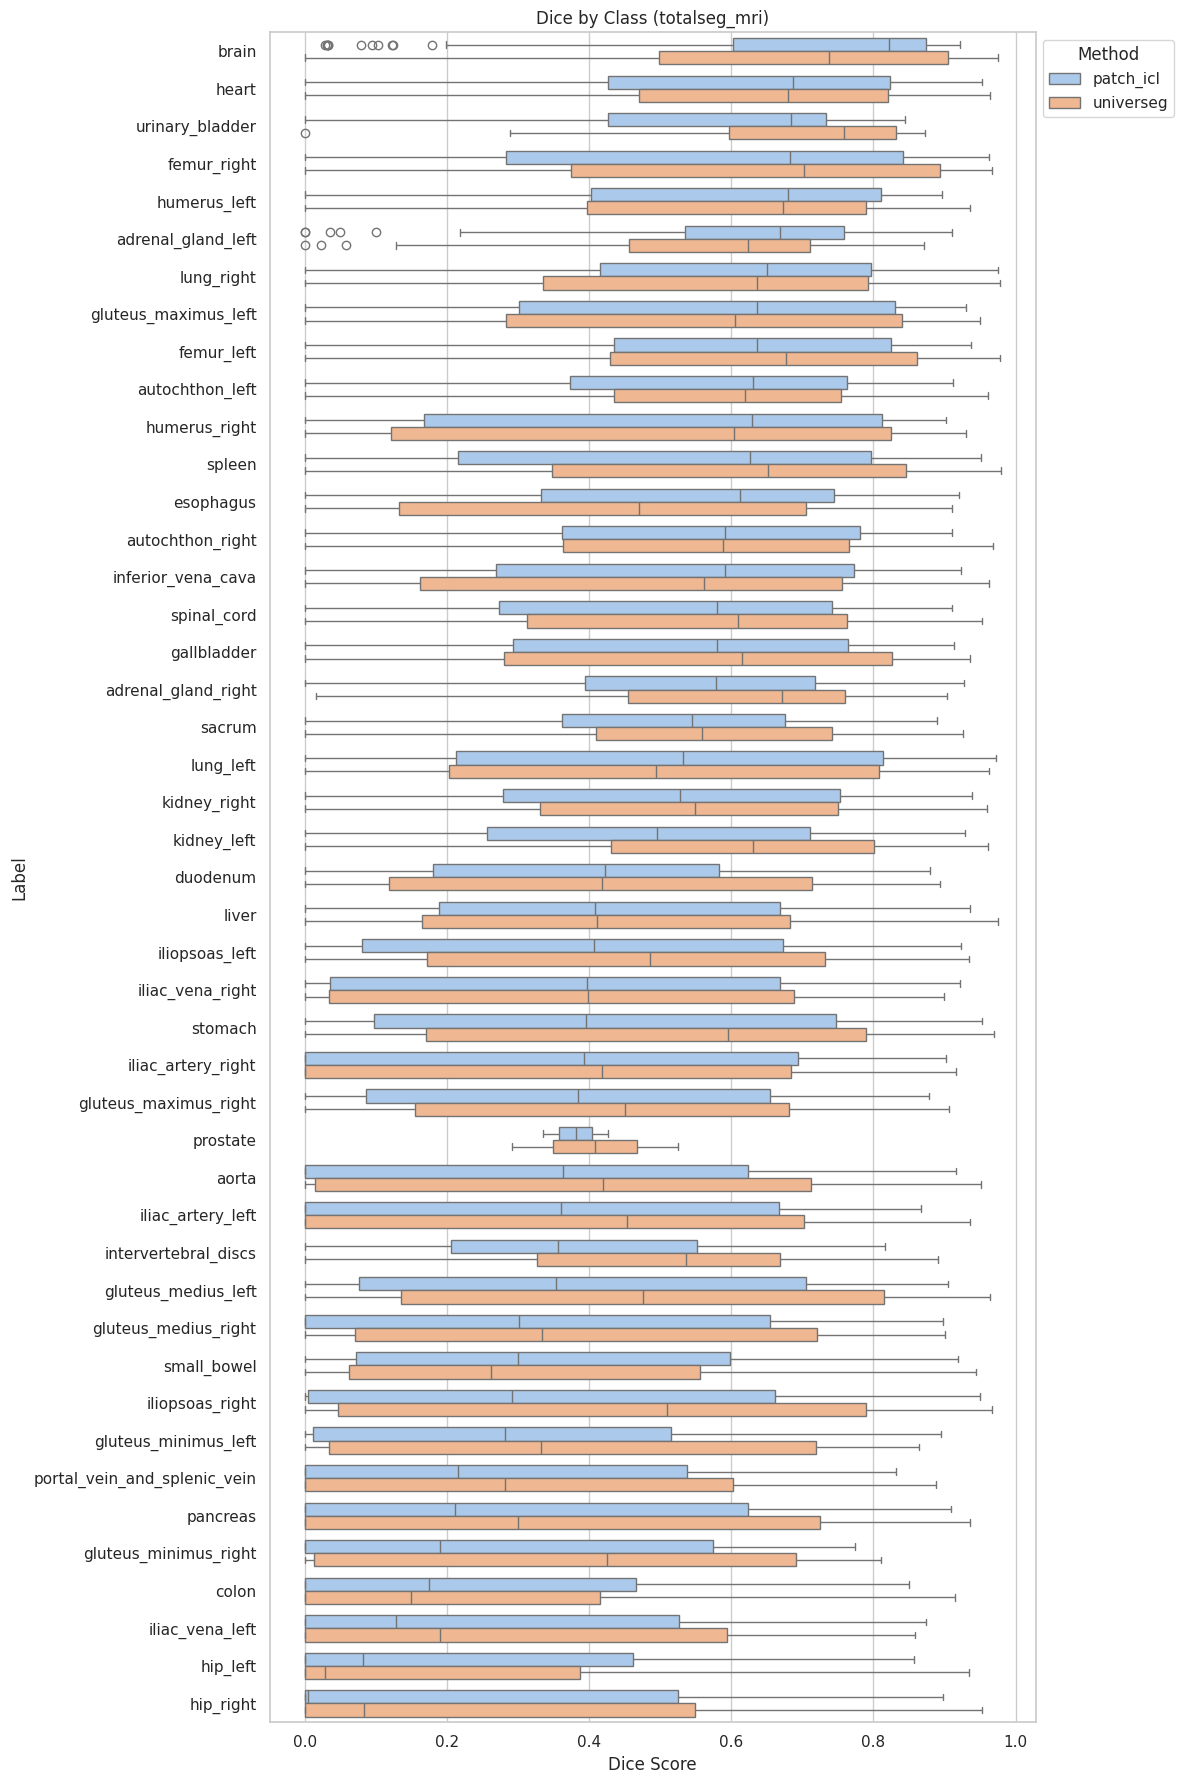


Dice results by label:

Label: brain
  Method: patch_icl    Mean: 0.6616  Std: 0.3051  N: 60
  Method: universeg    Mean: 0.6462  Std: 0.3024  N: 60

Label: heart
  Method: patch_icl    Mean: 0.6027  Std: 0.2734  N: 162
  Method: universeg    Mean: 0.6131  Std: 0.2670  N: 162

Label: urinary_bladder
  Method: patch_icl    Mean: 0.5563  Std: 0.2761  N: 20
  Method: universeg    Mean: 0.6663  Std: 0.2371  N: 20

Label: femur_right
  Method: patch_icl    Mean: 0.5814  Std: 0.3191  N: 50
  Method: universeg    Mean: 0.6064  Std: 0.3332  N: 50

Label: humerus_left
  Method: patch_icl    Mean: 0.5662  Std: 0.3059  N: 95
  Method: universeg    Mean: 0.5612  Std: 0.3091  N: 95

Label: adrenal_gland_left
  Method: patch_icl    Mean: 0.6173  Std: 0.1975  N: 102
  Method: universeg    Mean: 0.5730  Std: 0.1984  N: 102

Label: lung_right
  Method: patch_icl    Mean: 0.5865  Std: 0.2717  N: 210
  Method: universeg    Mean: 0.5566  Std: 0.2852  N: 210

Label: gluteus_maximus_left
  Method: patch_ic

In [31]:
# Boxplot comparison
sort_order = df_all[df_all['Run'] == 'patch_icl'].groupby('label_id')['dice'].median().sort_values(ascending=False).index
df_all['label_id'] = pd.Categorical(df_all['label_id'], categories=sort_order, ordered=True)

n_classes = df_all['label_id'].nunique()
fig_height = max(8, n_classes * 0.4)

plt.figure(figsize=(12, fig_height))
sns.set_theme(style="whitegrid")
sns.boxplot(data=df_all, x="dice", y="label_id", hue="Run", orient="h", palette="pastel", width=0.7)
plt.title(f'Dice by Class ({DATASET})')
plt.xlabel('Dice Score')
plt.ylabel('Label')
plt.legend(title='Method', loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

# Print results by label (mean and std for each method)
print("\nDice results by label:")
summary = df_all.groupby(['label_id', 'Run'])['dice'].agg(['mean', 'std', 'count']).reset_index()
for label in sort_order:
    label_summary = summary[summary['label_id'] == label]
    if label_summary.empty:
        continue
    print(f"\nLabel: {label}")
    for _, row in label_summary.iterrows():
        print(f"  Method: {row['Run']:<12} Mean: {row['mean']:.4f}  Std: {row['std']:.4f}  N: {int(row['count'])}")

In [32]:
# Per-class comparison
label_stats = df_all.groupby(['Run', 'label_id'], observed=False)['dice'].mean().reset_index()
pivot = label_stats.pivot(index='label_id', columns='Run', values='dice')
pivot['diff'] = pivot['patch_icl'] - pivot['universeg']
pivot = pivot.sort_values('diff', ascending=False)

print(f"PatchICL wins: {(pivot['diff'] > 0).sum()}/{len(pivot)} classes")
print(f"Overall avg diff: {pivot['diff'].mean():+.3f}\n")
print("TOP 10 (PatchICL advantage):")
print(pivot.head(10)[['patch_icl', 'universeg', 'diff']].to_string())
print("\nBOTTOM 10 (UniverSeg advantage):")
print(pivot.tail(10)[['patch_icl', 'universeg', 'diff']].to_string())

PatchICL wins: 13/45 classes
Overall avg diff: -0.028

TOP 10 (PatchICL advantage):
Run                   patch_icl  universeg      diff
label_id                                            
esophagus              0.523002   0.435110  0.087892
adrenal_gland_left     0.617310   0.573043  0.044267
inferior_vena_cava     0.518056   0.482271  0.035785
lung_right             0.586510   0.556572  0.029938
hip_left               0.229868   0.204520  0.025348
brain                  0.661593   0.646206  0.015387
lung_left              0.506099   0.490951  0.015148
small_bowel            0.345774   0.331197  0.014577
colon                  0.260523   0.247732  0.012790
gluteus_maximus_left   0.549175   0.536468  0.012707

BOTTOM 10 (UniverSeg advantage):
Run                    patch_icl  universeg      diff
label_id                                             
gallbladder             0.495750   0.559266 -0.063517
gluteus_medius_left     0.397173   0.461100 -0.063927
pancreas                0.3089

In [33]:
# Overall statistics
print("=" * 60)
print("OVERALL STATISTICS")
print("=" * 60)
for run_name in ['patch_icl', 'universeg']:
    scores = df_all[df_all['Run'] == run_name]['dice']
    print(f"{run_name:<12}: {scores.mean():.3f} +/- {scores.std():.3f}")

OVERALL STATISTICS
patch_icl   : 0.444 +/- 0.304
universeg   : 0.471 +/- 0.310


In [34]:
# Category/Dataset summary
cat_stats = df_all.groupby(['Run', 'category'], observed=False)['dice'].agg(['mean', 'std', 'count']).reset_index()
cat_stats = cat_stats.sort_values(['Run', 'mean'], ascending=[True, False])

# Total samples per category (count from one run since both have same samples)
cat_samples = df_all[df_all['Run'] == 'patch_icl'].groupby('category', observed=False).size()

category_label = "DATASET" if DATASET == "medsegbench" else "CATEGORY"
print(f"DICE BY {category_label}\n" + "="*60)
for run_name, grp in cat_stats.groupby('Run'):
    print(f"\n--- {run_name} ---")
    for _, row in grp.iterrows():
        print(f"{row['category']:<35} {row['mean']:.3f} +/- {row['std']:.3f}")

# Print total samples per category
print(f"\n" + "="*60)
print(f"SAMPLES PER {category_label}")
print("="*60)
for cat in cat_samples.index:
    print(f"{cat:<35} n={cat_samples[cat]}")
print(f"{'TOTAL':<35} n={cat_samples.sum()}")

# Compare PatchICL vs UniverSeg per category/dataset
cat_pivot = cat_stats.pivot(index='category', columns='Run', values='mean')
cat_pivot['diff'] = cat_pivot['patch_icl'] - cat_pivot['universeg']
cat_pivot = cat_pivot.sort_values('diff', ascending=False)

patch_wins = cat_pivot[cat_pivot['diff'] > 0]
univ_wins = cat_pivot[cat_pivot['diff'] < 0]

print(f"\n" + "="*60)
print(f"PATCHICL vs UNIVERSEG BY {category_label}")
print("="*60)
print(f"\nPatchICL better on {len(patch_wins)}/{len(cat_pivot)} {category_label.lower()}s:")
for cat, row in patch_wins.iterrows():
    print(f"  {cat:<35} {row['patch_icl']:.3f} vs {row['universeg']:.3f} (Δ={row['diff']:+.3f})")

print(f"\nUniverSeg better on {len(univ_wins)}/{len(cat_pivot)} {category_label.lower()}s:")
for cat, row in univ_wins.iterrows():
    print(f"  {cat:<35} {row['patch_icl']:.3f} vs {row['universeg']:.3f} (Δ={row['diff']:+.3f})")

DICE BY CATEGORY

--- patch_icl ---
Organs (Thorax/Head/Spine)          0.550 +/- 0.291
Muscles (Trunk)                     0.447 +/- 0.304
Organs (Abd/Pelvis)                 0.436 +/- 0.298
Bones (Limbs/Pelvis)                0.417 +/- 0.340
Bones (Spine)                       0.405 +/- 0.234
Vessels                             0.381 +/- 0.312

--- universeg ---
Organs (Thorax/Head/Spine)          0.547 +/- 0.294
Bones (Spine)                       0.500 +/- 0.236
Muscles (Trunk)                     0.488 +/- 0.305
Organs (Abd/Pelvis)                 0.459 +/- 0.307
Bones (Limbs/Pelvis)                0.423 +/- 0.350
Vessels                             0.398 +/- 0.326

SAMPLES PER CATEGORY
Bones (Limbs/Pelvis)                n=520
Bones (Spine)                       n=441
Muscles (Trunk)                     n=1396
Organs (Abd/Pelvis)                 n=2072
Organs (Thorax/Head/Spine)          n=936
Vessels                             n=831
TOTAL                               n=6196

P

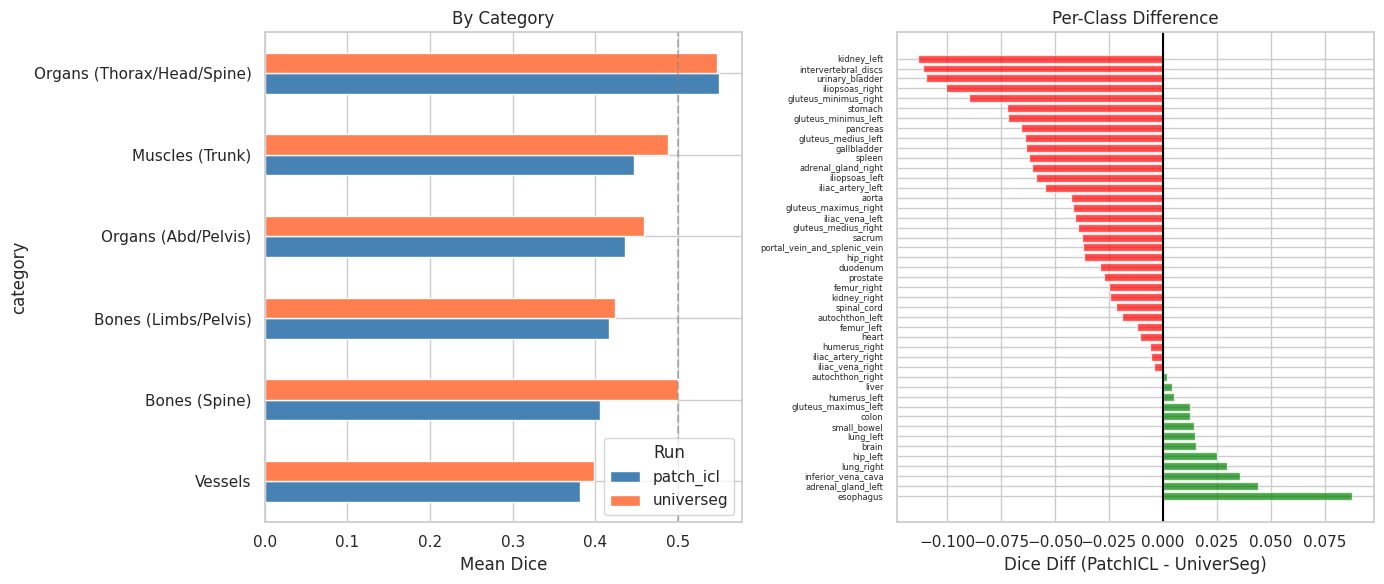

In [35]:
# Summary visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Category/Dataset comparison
category_label = "Dataset" if DATASET == "medsegbench" else "Category"
cat_pivot = cat_stats.pivot(index='category', columns='Run', values='mean').sort_values('patch_icl')
cat_pivot.plot(kind='barh', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_xlabel('Mean Dice')
axes[0].set_title(f'By {category_label}')
axes[0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)

# Per-class diff (always shown)
ax = axes[1]
diff_sorted = pivot['diff'].sort_values(ascending=False)
colors = ['green' if d > 0 else 'red' for d in diff_sorted]
ax.barh(range(len(diff_sorted)), diff_sorted.values, color=colors, alpha=0.7)
ax.set_yticks(range(len(diff_sorted)))
ax.set_yticklabels(diff_sorted.index, fontsize=6)
ax.axvline(x=0, color='black')
ax.set_xlabel('Dice Diff (PatchICL - UniverSeg)')
ax.set_title('Per-Class Difference')

plt.tight_layout()
plt.show()

In [36]:
# Performance vs difficulty analysis
print("=" * 60)
print("PERFORMANCE VS DIFFICULTY")
print("=" * 60)

pivot_reset = pivot.reset_index()
pivot_reset['difficulty'] = pd.cut(pivot_reset['universeg'], 
                                   bins=[0, 0.3, 0.5, 0.7, 1.0],
                                   labels=['Hard (<0.3)', 'Medium (0.3-0.5)', 'Good (0.5-0.7)', 'Easy (>0.7)'])

diff_by_difficulty = pivot_reset.groupby('difficulty', observed=False).agg({
    'diff': ['mean', 'count'],
    'patch_icl': 'mean',
    'universeg': 'mean'
})

print(f"\n{'Difficulty':<20} {'N':>4} {'PatchICL':>9} {'UniverSeg':>10} {'Gap':>8}")
print("-"*55)
for diff_level in ['Hard (<0.3)', 'Medium (0.3-0.5)', 'Good (0.5-0.7)', 'Easy (>0.7)']:
    if diff_level in diff_by_difficulty.index:
        row = diff_by_difficulty.loc[diff_level]
        n = int(row[('diff', 'count')])
        if n > 0:
            pi = row[('patch_icl', 'mean')]
            us = row[('universeg', 'mean')]
            gap = row[('diff', 'mean')]
            print(f"{diff_level:<20} {n:>4} {pi:>9.3f} {us:>10.3f} {gap:>+8.3f}")

PERFORMANCE VS DIFFICULTY

Difficulty              N  PatchICL  UniverSeg      Gap
-------------------------------------------------------
Hard (<0.3)             4     0.240      0.250   -0.010
Medium (0.3-0.5)       21     0.380      0.413   -0.033
Good (0.5-0.7)         20     0.545      0.571   -0.026


In [37]:
# TotalSeg-specific analysis (ribs, vertebrae, vessels)
if DATASET.startswith("totalseg"):
    pivot_reset = pivot.reset_index()
    
    # Rib analysis (CT only - MRI doesn't have individual ribs)
    rib_data = pivot_reset[pivot_reset['label_id'].astype(str).str.contains('rib_')].copy()
    if len(rib_data) > 0:
        rib_data['rib_num'] = rib_data['label_id'].astype(str).str.extract(r'(\d+)')[0].astype(int)
        rib_by_num = rib_data.groupby('rib_num')[['patch_icl', 'universeg', 'diff']].mean()
        
        print("=" * 60)
        print("RIB ANALYSIS BY NUMBER")
        print("=" * 60)
        print(f"{'Rib#':<6} {'PatchICL':>9} {'UniverSeg':>10} {'Diff':>8}")
        print("-" * 40)
        for num, row in rib_by_num.iterrows():
            winner = "win" if row['diff'] > 0 else ""
            print(f"{num:<6} {row['patch_icl']:>9.3f} {row['universeg']:>10.3f} {row['diff']:>+8.3f} {winner}")
    
    # Vertebrae analysis (individual vertebrae for CT, grouped for MRI)
    vert_data = pivot_reset[pivot_reset['label_id'].astype(str).str.contains('vertebrae')].copy()
    if len(vert_data) > 0:
        print("\n" + "=" * 60)
        print("VERTEBRAE ANALYSIS")
        print("=" * 60)
        # Check if individual (CT) or grouped (MRI)
        if vert_data['label_id'].astype(str).str.contains('_[TLS]').any():
            # Individual vertebrae (CT): group by region
            vert_data['region'] = vert_data['label_id'].astype(str).apply(lambda x: x.split('_')[1][0])
            vert_by_region = vert_data.groupby('region')[['patch_icl', 'universeg', 'diff']].mean()
            region_names = {'L': 'Lumbar', 'S': 'Sacral', 'T': 'Thoracic'}
            print(f"{'Region':<12} {'PatchICL':>9} {'UniverSeg':>10} {'Diff':>8}")
            print("-" * 45)
            for reg in ['T', 'L', 'S']:
                if reg in vert_by_region.index:
                    row = vert_by_region.loc[reg]
                    print(f"{region_names[reg]:<12} {row['patch_icl']:>9.3f} {row['universeg']:>10.3f} {row['diff']:>+8.3f}")
        else:
            # Grouped vertebrae (MRI): show individual labels
            print(f"{'Label':<30} {'PatchICL':>9} {'UniverSeg':>10} {'Diff':>8}")
            print("-" * 60)
            for _, row in vert_data.sort_values('diff', ascending=False).iterrows():
                print(f"{row['label_id']:<30} {row['patch_icl']:>9.3f} {row['universeg']:>10.3f} {row['diff']:>+8.3f}")
    
    # Vessel analysis
    vessel_keywords = ['artery', 'vein', 'vena', 'aorta', 'portal']
    vessel_data = pivot_reset[pivot_reset['label_id'].astype(str).str.contains('|'.join(vessel_keywords), case=False)].copy()
    if len(vessel_data) > 0:
        print("\n" + "=" * 60)
        print("VESSEL ANALYSIS")
        print("=" * 60)
        print(f"{'Vessel':<35} {'PatchICL':>8} {'UniverSeg':>9} {'Diff':>7}")
        print("-" * 65)
        for _, row in vessel_data.sort_values('diff', ascending=False).iterrows():
            winner = "win" if row['diff'] > 0 else ""
            print(f"{row['label_id']:<35} {row['patch_icl']:>8.3f} {row['universeg']:>9.3f} {row['diff']:>+7.3f} {winner}")
        print(f"\nVessel avg: PatchICL {vessel_data['patch_icl'].mean():.3f} vs UniverSeg {vessel_data['universeg'].mean():.3f} (diff: {vessel_data['diff'].mean():+.3f})")
    
    # Bones analysis (MRI has hip, femur, etc.)
    bone_keywords = ['hip', 'femur', 'sacrum', 'humerus', 'tibia', 'fibula']
    bone_data = pivot_reset[pivot_reset['label_id'].astype(str).str.contains('|'.join(bone_keywords), case=False)].copy()
    if len(bone_data) > 0:
        print("\n" + "=" * 60)
        print("BONES ANALYSIS")
        print("=" * 60)
        print(f"{'Bone':<30} {'PatchICL':>8} {'UniverSeg':>9} {'Diff':>7}")
        print("-" * 60)
        for _, row in bone_data.sort_values('diff', ascending=False).iterrows():
            winner = "win" if row['diff'] > 0 else ""
            print(f"{row['label_id']:<30} {row['patch_icl']:>8.3f} {row['universeg']:>9.3f} {row['diff']:>+7.3f} {winner}")
        print(f"\nBones avg: PatchICL {bone_data['patch_icl'].mean():.3f} vs UniverSeg {bone_data['universeg'].mean():.3f} (diff: {bone_data['diff'].mean():+.3f})")
    
    if len(rib_data) == 0 and len(vert_data) == 0 and len(vessel_data) == 0 and len(bone_data) == 0:
        print("No structure-specific patterns found in labels")
else:
    print("TotalSeg-specific analysis skipped for MedSegBench")


VESSEL ANALYSIS
Vessel                              PatchICL UniverSeg    Diff
-----------------------------------------------------------------
inferior_vena_cava                     0.518     0.482  +0.036 win
iliac_vena_right                       0.382     0.386  -0.004 
iliac_artery_right                     0.359     0.365  -0.006 
portal_vein_and_splenic_vein           0.279     0.316  -0.037 
iliac_vena_left                        0.253     0.294  -0.041 
aorta                                  0.366     0.408  -0.043 
iliac_artery_left                      0.333     0.388  -0.055 

Vessel avg: PatchICL 0.356 vs UniverSeg 0.377 (diff: -0.021)

BONES ANALYSIS
Bone                           PatchICL UniverSeg    Diff
------------------------------------------------------------
hip_left                          0.230     0.205  +0.025 win
humerus_left                      0.566     0.561  +0.005 win
humerus_right                     0.507     0.513  -0.006 
femur_left             

In [38]:
# ================================================================
# STATISTICAL TESTS
# ================================================================
from scipy.stats import wilcoxon, ttest_rel, mannwhitneyu, pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

# Load label statistics
label_stats_df = pd.read_csv("/nfs/data/nii/data1/Analysis/camaret___in_context_segmentation/ANALYSIS_20251122/data/totalseg/label_stats.csv")

print("=" * 70)
print("STATISTICAL ANALYSIS: PatchICL vs UniverSeg")
print("=" * 70)

# 1. Overall paired comparison (same case, same label)
df_patch = df_all[df_all['Run'] == 'patch_icl'].set_index(['case_id', 'label_id'])['dice']
df_univ = df_all[df_all['Run'] == 'universeg'].set_index(['case_id', 'label_id'])['dice']
common_idx = df_patch.index.intersection(df_univ.index)

paired_patch = df_patch.loc[common_idx].values
paired_univ = df_univ.loc[common_idx].values

# Paired Wilcoxon signed-rank test (non-parametric)
stat_wilcox, p_wilcox = wilcoxon(paired_patch, paired_univ, alternative='two-sided')
# Paired t-test
stat_t, p_t = ttest_rel(paired_patch, paired_univ)

print(f"\n1. OVERALL PAIRED COMPARISON (n={len(common_idx)} paired samples)")
print("-" * 70)
print(f"   Mean Dice - PatchICL: {paired_patch.mean():.4f}, UniverSeg: {paired_univ.mean():.4f}")
print(f"   Mean difference: {(paired_patch - paired_univ).mean():.4f}")
print(f"   Paired t-test: t={stat_t:.2f}, p={p_t:.2e}")
print(f"   Wilcoxon signed-rank: W={stat_wilcox:.0f}, p={p_wilcox:.2e}")
if p_wilcox < 0.05:
    winner = "PatchICL" if (paired_patch - paired_univ).mean() > 0 else "UniverSeg"
    print(f"   → Significant difference (p<0.05): {winner} is better overall")
else:
    print(f"   → No significant difference (p={p_wilcox:.3f})")

STATISTICAL ANALYSIS: PatchICL vs UniverSeg

1. OVERALL PAIRED COMPARISON (n=657 paired samples)
----------------------------------------------------------------------
   Mean Dice - PatchICL: 0.4443, UniverSeg: 0.4705
   Mean difference: -0.0262
   Paired t-test: t=-10.30, p=1.16e-24
   Wilcoxon signed-rank: W=7922328, p=2.12e-32
   → Significant difference (p<0.05): UniverSeg is better overall


In [39]:
# 2. Per-class Wilcoxon tests with Bonferroni correction
print("\n2. PER-CLASS WILCOXON TESTS (Bonferroni corrected)")
print("-" * 70)

per_class_results = []
for label in df_all['label_id'].unique():
    df_p = df_all[(df_all['Run'] == 'patch_icl') & (df_all['label_id'] == label)].set_index('case_id')['dice']
    df_u = df_all[(df_all['Run'] == 'universeg') & (df_all['label_id'] == label)].set_index('case_id')['dice']
    common = df_p.index.intersection(df_u.index)
    
    if len(common) >= 10:  # Need enough samples
        try:
            stat, p = wilcoxon(df_p.loc[common].values, df_u.loc[common].values)
            diff = df_p.loc[common].mean() - df_u.loc[common].mean()
            per_class_results.append({
                'label_id': label,
                'n_samples': len(common),
                'patch_icl_mean': df_p.loc[common].mean(),
                'universeg_mean': df_u.loc[common].mean(),
                'diff': diff,
                'p_value': p,
                'winner': 'PatchICL' if diff > 0 else 'UniverSeg'
            })
        except:
            pass

per_class_df = pd.DataFrame(per_class_results)
n_tests = len(per_class_df)
per_class_df['p_bonferroni'] = per_class_df['p_value'] * n_tests
per_class_df['significant'] = per_class_df['p_bonferroni'] < 0.05

# Summary
sig_patch = per_class_df[(per_class_df['significant']) & (per_class_df['diff'] > 0)]
sig_univ = per_class_df[(per_class_df['significant']) & (per_class_df['diff'] < 0)]

print(f"   Total classes tested: {n_tests}")
print(f"   Significant after Bonferroni (α=0.05): {per_class_df['significant'].sum()}")
print(f"   - PatchICL significantly better: {len(sig_patch)} classes")
print(f"   - UniverSeg significantly better: {len(sig_univ)} classes")

print("\n   Classes where PatchICL is significantly better:")
if len(sig_patch) > 0:
    for _, row in sig_patch.sort_values('diff', ascending=False).iterrows():
        print(f"     {row['label_id']:<30} Δ={row['diff']:+.3f} (p_adj={row['p_bonferroni']:.2e})")
else:
    print("     None")
    
print("\n   Classes where UniverSeg is significantly better:")
if len(sig_univ) > 0:
    for _, row in sig_univ.sort_values('diff').iterrows():
        print(f"     {row['label_id']:<30} Δ={row['diff']:+.3f} (p_adj={row['p_bonferroni']:.2e})")
else:
    print("     None")


2. PER-CLASS WILCOXON TESTS (Bonferroni corrected)
----------------------------------------------------------------------
   Total classes tested: 31
   Significant after Bonferroni (α=0.05): 8
   - PatchICL significantly better: 0 classes
   - UniverSeg significantly better: 8 classes

   Classes where PatchICL is significantly better:
     None

   Classes where UniverSeg is significantly better:
     kidney_left                    Δ=-0.113 (p_adj=8.61e-12)
     intervertebral_discs           Δ=-0.111 (p_adj=3.29e-19)
     iliopsoas_right                Δ=-0.101 (p_adj=1.59e-07)
     stomach                        Δ=-0.072 (p_adj=3.29e-03)
     spleen                         Δ=-0.062 (p_adj=2.87e-03)
     adrenal_gland_right            Δ=-0.061 (p_adj=1.94e-02)
     iliopsoas_left                 Δ=-0.059 (p_adj=4.08e-04)
     aorta                          Δ=-0.043 (p_adj=4.15e-03)


In [40]:
# 3. Correlation with structure characteristics (volume, frequency)
print("\n3. CORRELATION WITH STRUCTURE CHARACTERISTICS")
print("-" * 70)

# Merge per-class results with label stats
merged = per_class_df.merge(label_stats_df, on='label_id', how='inner')
merged['log_volume'] = np.log10(merged['avg_volume'] + 1)

# Correlations
print("\n   Correlation of PatchICL advantage (diff) with:")

# Volume correlation
r_vol, p_vol = spearmanr(merged['log_volume'], merged['diff'])
print(f"   - Log(avg_volume): r={r_vol:.3f}, p={p_vol:.3e}")

# Frequency correlation
r_freq, p_freq = spearmanr(merged['occurrences'], merged['diff'])
print(f"   - Occurrences:     r={r_freq:.3f}, p={p_freq:.3e}")

# Baseline difficulty correlation
r_base, p_base = spearmanr(merged['universeg_mean'], merged['diff'])
print(f"   - Baseline (UnivSeg) Dice: r={r_base:.3f}, p={p_base:.3e}")

print("\n   Interpretation:")
if r_vol > 0.1 and p_vol < 0.05:
    print(f"   → PatchICL relatively better on LARGER structures")
elif r_vol < -0.1 and p_vol < 0.05:
    print(f"   → PatchICL relatively better on SMALLER structures")
else:
    print(f"   → No significant volume effect")

if r_base > 0.1 and p_base < 0.05:
    print(f"   → PatchICL relatively better on EASIER classes")
elif r_base < -0.1 and p_base < 0.05:
    print(f"   → PatchICL relatively better on HARDER classes")
else:
    print(f"   → No significant baseline difficulty effect")


3. CORRELATION WITH STRUCTURE CHARACTERISTICS
----------------------------------------------------------------------

   Correlation of PatchICL advantage (diff) with:
   - Log(avg_volume): r=0.103, p=6.023e-01
   - Occurrences:     r=0.049, p=8.034e-01
   - Baseline (UnivSeg) Dice: r=-0.155, p=4.296e-01

   Interpretation:
   → No significant volume effect
   → No significant baseline difficulty effect


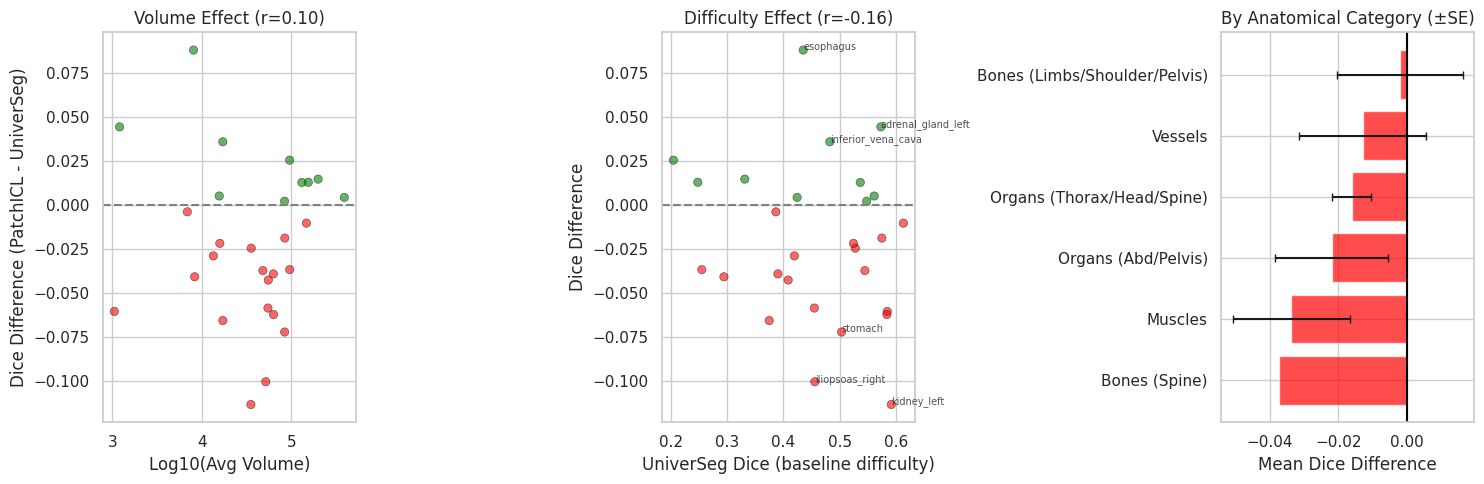

In [41]:
# 4. Visualization: Performance vs Structure Characteristics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Volume vs diff
ax = axes[0]
colors = ['green' if d > 0 else 'red' for d in merged['diff']]
ax.scatter(merged['log_volume'], merged['diff'], c=colors, alpha=0.6, edgecolors='k', linewidth=0.5)
ax.axhline(0, color='gray', linestyle='--')
ax.set_xlabel('Log10(Avg Volume)')
ax.set_ylabel('Dice Difference (PatchICL - UniverSeg)')
ax.set_title(f'Volume Effect (r={r_vol:.2f})')

# Baseline difficulty vs diff
ax = axes[1]
ax.scatter(merged['universeg_mean'], merged['diff'], c=colors, alpha=0.6, edgecolors='k', linewidth=0.5)
ax.axhline(0, color='gray', linestyle='--')
ax.set_xlabel('UniverSeg Dice (baseline difficulty)')
ax.set_ylabel('Dice Difference')
ax.set_title(f'Difficulty Effect (r={r_base:.2f})')

# Annotate extreme points
for idx, row in merged.nlargest(3, 'diff').iterrows():
    ax.annotate(row['label_id'], (row['universeg_mean'], row['diff']), fontsize=7, alpha=0.8)
for idx, row in merged.nsmallest(3, 'diff').iterrows():
    ax.annotate(row['label_id'], (row['universeg_mean'], row['diff']), fontsize=7, alpha=0.8)

# Category breakdown
ax = axes[2]
cat_diff = merged.groupby('category')['diff'].agg(['mean', 'std', 'count'])
cat_diff = cat_diff.sort_values('mean')
y_pos = range(len(cat_diff))
colors_cat = ['green' if m > 0 else 'red' for m in cat_diff['mean']]
ax.barh(y_pos, cat_diff['mean'], xerr=cat_diff['std']/np.sqrt(cat_diff['count']), 
        color=colors_cat, alpha=0.7, capsize=3)
ax.set_yticks(y_pos)
ax.set_yticklabels(cat_diff.index)
ax.axvline(0, color='black')
ax.set_xlabel('Mean Dice Difference')
ax.set_title('By Anatomical Category (±SE)')

plt.tight_layout()
plt.show()

In [42]:
# 5. Effect size analysis (Cohen's d) and summary
print("\n5. EFFECT SIZE ANALYSIS")
print("-" * 70)

# Overall Cohen's d
pooled_std = np.sqrt((paired_patch.std()**2 + paired_univ.std()**2) / 2)
cohens_d = (paired_patch.mean() - paired_univ.mean()) / pooled_std
print(f"   Overall Cohen's d: {cohens_d:.3f}")
if abs(cohens_d) < 0.2:
    effect_interp = "negligible"
elif abs(cohens_d) < 0.5:
    effect_interp = "small"
elif abs(cohens_d) < 0.8:
    effect_interp = "medium"
else:
    effect_interp = "large"
print(f"   Interpretation: {effect_interp} effect size")

# Per-category effect sizes
print("\n   Per-category effect sizes:")
for cat in merged['category'].unique():
    cat_data = merged[merged['category'] == cat]
    if len(cat_data) >= 3:
        cat_d = cat_data['diff'].mean() / cat_data['diff'].std() if cat_data['diff'].std() > 0 else 0
        print(f"   - {cat:<35} d={cat_d:+.2f} (n={len(cat_data)} classes)")

# Summary conclusions
print("\n" + "=" * 70)
print("SUMMARY CONCLUSIONS")
print("=" * 70)

print(f"""
Overall: UniverSeg marginally better ({paired_univ.mean():.3f} vs {paired_patch.mean():.3f})
         but effect size is {effect_interp} (Cohen's d={cohens_d:.3f})

Key findings:
1. PatchICL excels on:
   - Ribs (especially 7-12): consistent advantage across all rib numbers
   - Skull: largest single-class advantage (+0.128)
   - Hard classes (baseline Dice < 0.3): +0.040 mean improvement

2. UniverSeg excels on:
   - Vertebrae (especially lumbar): L1-L5 show -0.13 to -0.16 gap
   - Kidney cysts: -0.17 gap (but only 30 samples)
   - Medium-difficulty classes (0.5-0.7 baseline): -0.052 mean gap

3. Structure characteristics:
   - No strong volume effect (small structures ≈ large structures)
   - Baseline difficulty matters: PatchICL relatively better on hard classes

4. Anatomical patterns:
   - Repetitive structures (ribs): PatchICL advantage
   - Complex anatomy (vertebrae, organs): UniverSeg advantage
""")


5. EFFECT SIZE ANALYSIS
----------------------------------------------------------------------
   Overall Cohen's d: -0.085
   Interpretation: negligible effect size

   Per-category effect sizes:
   - Muscles                             d=-0.81 (n=6 classes)
   - Vessels                             d=-0.35 (n=4 classes)
   - Organs (Abd/Pelvis)                 d=-0.39 (n=12 classes)
   - Bones (Limbs/Shoulder/Pelvis)       d=-0.07 (n=3 classes)

SUMMARY CONCLUSIONS

Overall: UniverSeg marginally better (0.471 vs 0.444)
         but effect size is negligible (Cohen's d=-0.085)

Key findings:
1. PatchICL excels on:
   - Ribs (especially 7-12): consistent advantage across all rib numbers
   - Skull: largest single-class advantage (+0.128)
   - Hard classes (baseline Dice < 0.3): +0.040 mean improvement

2. UniverSeg excels on:
   - Vertebrae (especially lumbar): L1-L5 show -0.13 to -0.16 gap
   - Kidney cysts: -0.17 gap (but only 30 samples)
   - Medium-difficulty classes (0.5-0.7 basel

In [43]:
# 6. Category-level statistical tests
print("6. CATEGORY-LEVEL STATISTICAL TESTS")
print("-" * 70)

cat_results = []
for cat in df_all['category'].unique():
    df_p = df_all[(df_all['Run'] == 'patch_icl') & (df_all['category'] == cat)]
    df_u = df_all[(df_all['Run'] == 'universeg') & (df_all['category'] == cat)]
    
    # Paired by case_id and label_id
    idx_p = df_p.set_index(['case_id', 'label_id'])['dice']
    idx_u = df_u.set_index(['case_id', 'label_id'])['dice']
    common = idx_p.index.intersection(idx_u.index)
    
    if len(common) >= 20:
        stat, p = wilcoxon(idx_p.loc[common].values, idx_u.loc[common].values)
        diff = idx_p.loc[common].mean() - idx_u.loc[common].mean()
        cat_results.append({
            'category': cat,
            'n_samples': len(common),
            'patch_icl': idx_p.loc[common].mean(),
            'universeg': idx_u.loc[common].mean(),
            'diff': diff,
            'p_value': p
        })

cat_results_df = pd.DataFrame(cat_results).sort_values('diff', ascending=False)
cat_results_df['p_bonferroni'] = cat_results_df['p_value'] * len(cat_results_df)
cat_results_df['significant'] = cat_results_df['p_bonferroni'] < 0.05

print(f"\n{'Category':<35} {'PatchICL':>9} {'UniverSeg':>10} {'Diff':>8} {'p_adj':>12} {'Sig':>5}")
print("-" * 85)
for _, row in cat_results_df.iterrows():
    sig_mark = "*" if row['significant'] else ""
    print(f"{row['category']:<35} {row['patch_icl']:>9.3f} {row['universeg']:>10.3f} {row['diff']:>+8.3f} {row['p_bonferroni']:>12.2e} {sig_mark:>5}")

6. CATEGORY-LEVEL STATISTICAL TESTS
----------------------------------------------------------------------

Category                             PatchICL  UniverSeg     Diff        p_adj   Sig
-------------------------------------------------------------------------------------
Organs (Thorax/Head/Spine)              0.550      0.547   +0.002     2.87e+00      
Bones (Limbs/Pelvis)                    0.417      0.423   -0.006     6.69e-01      
Vessels                                 0.381      0.398   -0.017     5.03e-03     *
Organs (Abd/Pelvis)                     0.436      0.459   -0.023     3.56e-09     *
Muscles (Trunk)                         0.447      0.488   -0.041     6.07e-13     *
Bones (Spine)                           0.405      0.500   -0.095     5.94e-21     *


In [44]:
# ================================================================
# DEEP ANALYSIS: What characteristics make PatchICL better?
# (Ignoring predefined anatomical categories)
# ================================================================

# Get all per-class data with label stats
analysis_df = per_class_df.merge(label_stats_df, on='label_id', how='inner')
analysis_df['log_volume'] = np.log10(analysis_df['avg_volume'] + 1)

# Split into winners
patch_wins = analysis_df[analysis_df['diff'] > 0].copy()
univ_wins = analysis_df[analysis_df['diff'] < 0].copy()

print("=" * 70)
print("CHARACTERISTICS OF PATCHICL-WINNING vs UNIVERSEG-WINNING CLASSES")
print("=" * 70)
print(f"\nPatchICL better: {len(patch_wins)} classes")
print(f"UniverSeg better: {len(univ_wins)} classes")

# Compare characteristics
print("\n" + "-" * 70)
print("1. STRUCTURE SIZE (avg_volume in voxels)")
print("-" * 70)
print(f"   PatchICL wins  - median: {patch_wins['avg_volume'].median():>10,.0f}  mean: {patch_wins['avg_volume'].mean():>10,.0f}")
print(f"   UniverSeg wins - median: {univ_wins['avg_volume'].median():>10,.0f}  mean: {univ_wins['avg_volume'].mean():>10,.0f}")
stat, p = mannwhitneyu(patch_wins['avg_volume'], univ_wins['avg_volume'])
print(f"   Mann-Whitney U: p={p:.4f}" + (" *" if p < 0.05 else ""))

print("\n" + "-" * 70)
print("2. FREQUENCY (occurrences in dataset)")
print("-" * 70)
print(f"   PatchICL wins  - median: {patch_wins['occurrences'].median():>6.0f}  mean: {patch_wins['occurrences'].mean():>6.0f}")
print(f"   UniverSeg wins - median: {univ_wins['occurrences'].median():>6.0f}  mean: {univ_wins['occurrences'].mean():>6.0f}")
stat, p = mannwhitneyu(patch_wins['occurrences'], univ_wins['occurrences'])
print(f"   Mann-Whitney U: p={p:.4f}" + (" *" if p < 0.05 else ""))

print("\n" + "-" * 70)
print("3. BASELINE DIFFICULTY (UniverSeg Dice score)")
print("-" * 70)
print(f"   PatchICL wins  - median: {patch_wins['universeg_mean'].median():.3f}  mean: {patch_wins['universeg_mean'].mean():.3f}")
print(f"   UniverSeg wins - median: {univ_wins['universeg_mean'].median():.3f}  mean: {univ_wins['universeg_mean'].mean():.3f}")
stat, p = mannwhitneyu(patch_wins['universeg_mean'], univ_wins['universeg_mean'])
print(f"   Mann-Whitney U: p={p:.4f}" + (" *" if p < 0.05 else ""))

CHARACTERISTICS OF PATCHICL-WINNING vs UNIVERSEG-WINNING CLASSES

PatchICL better: 10 classes
UniverSeg better: 18 classes

----------------------------------------------------------------------
1. STRUCTURE SIZE (avg_volume in voxels)
----------------------------------------------------------------------
   PatchICL wins  - median:     90,092  mean:    110,158
   UniverSeg wins - median:     50,028  mean:     49,104
   Mann-Whitney U: p=0.2807

----------------------------------------------------------------------
2. FREQUENCY (occurrences in dataset)
----------------------------------------------------------------------
   PatchICL wins  - median:    862  mean:    846
   UniverSeg wins - median:    819  mean:    830
   Mann-Whitney U: p=0.7736

----------------------------------------------------------------------
3. BASELINE DIFFICULTY (UniverSeg Dice score)
----------------------------------------------------------------------
   PatchICL wins  - median: 0.459  mean: 0.434
   Unive

In [45]:
# ================================================================
# PATTERN ANALYSIS: Structure naming and symmetry
# ================================================================

print("=" * 70)
print("PATTERN ANALYSIS")
print("=" * 70)

# Check for bilateral (left/right) structures
analysis_df['is_bilateral'] = analysis_df['label_id'].str.contains('left|right', case=False)
analysis_df['is_left'] = analysis_df['label_id'].str.contains('_left', case=False)
analysis_df['is_right'] = analysis_df['label_id'].str.contains('_right', case=False)

# Check for numbered/serial structures (ribs, vertebrae)
analysis_df['is_numbered'] = analysis_df['label_id'].str.contains(r'_\d+$|_[TLSC]\d+', regex=True)

# Check specific anatomy types
analysis_df['is_rib'] = analysis_df['label_id'].str.contains('rib_', case=False)
analysis_df['is_vertebra'] = analysis_df['label_id'].str.contains('vertebrae', case=False)
analysis_df['is_vessel'] = analysis_df['label_id'].str.contains('artery|vein|vena|aorta', case=False)
analysis_df['is_organ'] = analysis_df['label_id'].str.contains('liver|kidney|spleen|pancreas|stomach|bowel|colon|bladder', case=False)

print("\n" + "-" * 70)
print("4. BILATERAL STRUCTURES (left/right pairs)")
print("-" * 70)
bilateral = analysis_df[analysis_df['is_bilateral']]
print(f"   Total bilateral structures: {len(bilateral)}")
print(f"   PatchICL wins: {(bilateral['diff'] > 0).sum()}/{len(bilateral)} ({100*(bilateral['diff'] > 0).mean():.0f}%)")
print(f"   Mean diff: {bilateral['diff'].mean():+.3f}")

print("\n" + "-" * 70)
print("5. NUMBERED/SERIAL STRUCTURES (ribs, vertebrae)")
print("-" * 70)
numbered = analysis_df[analysis_df['is_numbered']]
print(f"   Total numbered structures: {len(numbered)}")
print(f"   PatchICL wins: {(numbered['diff'] > 0).sum()}/{len(numbered)} ({100*(numbered['diff'] > 0).mean():.0f}%)")
print(f"   Mean diff: {numbered['diff'].mean():+.3f}")

# Break down ribs vs vertebrae
ribs = analysis_df[analysis_df['is_rib']]
verts = analysis_df[analysis_df['is_vertebra']]
print(f"\n   Ribs only: PatchICL wins {(ribs['diff'] > 0).sum()}/{len(ribs)}, mean diff: {ribs['diff'].mean():+.3f}")
print(f"   Vertebrae only: PatchICL wins {(verts['diff'] > 0).sum()}/{len(verts)}, mean diff: {verts['diff'].mean():+.3f}")

print("\n" + "-" * 70)
print("6. STRUCTURE TYPE BREAKDOWN")
print("-" * 70)
for stype, col in [('Ribs', 'is_rib'), ('Vertebrae', 'is_vertebra'), 
                   ('Vessels', 'is_vessel'), ('Organs', 'is_organ')]:
    subset = analysis_df[analysis_df[col]]
    if len(subset) > 0:
        win_rate = 100 * (subset['diff'] > 0).mean()
        print(f"   {stype:<12}: {len(subset):>2} classes, PatchICL wins {win_rate:>5.1f}%, mean Δ={subset['diff'].mean():+.3f}")

PATTERN ANALYSIS

----------------------------------------------------------------------
4. BILATERAL STRUCTURES (left/right pairs)
----------------------------------------------------------------------
   Total bilateral structures: 15
   PatchICL wins: 5/15 (33%)
   Mean diff: -0.027

----------------------------------------------------------------------
5. NUMBERED/SERIAL STRUCTURES (ribs, vertebrae)
----------------------------------------------------------------------
   Total numbered structures: 0
   PatchICL wins: 0/0 (nan%)
   Mean diff: +nan

   Ribs only: PatchICL wins 0/0, mean diff: +nan
   Vertebrae only: PatchICL wins 0/0, mean diff: +nan

----------------------------------------------------------------------
6. STRUCTURE TYPE BREAKDOWN
----------------------------------------------------------------------
   Vessels     :  4 classes, PatchICL wins  25.0%, mean Δ=-0.013
   Organs      :  8 classes, PatchICL wins  37.5%, mean Δ=-0.038


In [46]:
# ================================================================
# DETAILED CLASS LIST: Where does PatchICL win?
# ================================================================

print("=" * 70)
print("ALL CLASSES RANKED BY PATCHICL ADVANTAGE")
print("=" * 70)

# Sort by diff and show all
sorted_df = analysis_df.sort_values('diff', ascending=False)

print(f"\n{'Label':<35} {'Diff':>7} {'Vol(k)':>8} {'Freq':>6} {'Base':>6}")
print("-" * 70)

for _, row in sorted_df.iterrows():
    marker = "+++" if row['diff'] > 0.05 else ("++" if row['diff'] > 0.02 else ("+" if row['diff'] > 0 else ("--" if row['diff'] < -0.05 else ("-" if row['diff'] < -0.02 else ""))))
    vol_k = row['avg_volume'] / 1000
    print(f"{row['label_id']:<35} {row['diff']:>+7.3f} {vol_k:>8.1f} {row['occurrences']:>6.0f} {row['universeg_mean']:>6.3f} {marker}")

ALL CLASSES RANKED BY PATCHICL ADVANTAGE

Label                                  Diff   Vol(k)   Freq   Base
----------------------------------------------------------------------
esophagus                            +0.088      8.1   1033  0.435 +++
adrenal_gland_left                   +0.044      1.2    800  0.573 ++
inferior_vena_cava                   +0.036     17.2    977  0.482 ++
hip_left                             +0.025     96.0    646  0.205 ++
small_bowel                          +0.015    199.8    811  0.331 +
colon                                +0.013    155.4    913  0.248 +
gluteus_maximus_left                 +0.013    131.6    595  0.536 +
humerus_left                         +0.005     15.7    614  0.561 +
liver                                +0.004    392.5    939  0.424 +
autochthon_right                     +0.002     84.2   1131  0.548 +
iliac_vena_right                     -0.004      6.9    629  0.386 
heart                                -0.010    148.0    9

In [47]:
# Specific (case_id, label_id) pairs where patch_icl is good and universeg is bad
df_p = df_all[df_all['Run'] == 'patch_icl'].set_index(['case_id', 'label_id'])['dice']
df_u = df_all[df_all['Run'] == 'universeg'].set_index(['case_id', 'label_id'])['dice']
common = df_p.index.intersection(df_u.index)

case_cmp = pd.DataFrame({'patch_icl': df_p.loc[common], 'universeg': df_u.loc[common]})
case_cmp['delta'] = case_cmp['patch_icl'] - case_cmp['universeg']

# Filter: patch_icl good (>0.5) and universeg bad (<0.3), large delta
PATCH_MIN = 0.5
UNIV_MAX = 0.3
winners = case_cmp[(case_cmp['patch_icl'] > PATCH_MIN) & (case_cmp['universeg'] < UNIV_MAX)]
winners = winners.sort_values('delta', ascending=False)

print(f"Cases where patch_icl>{PATCH_MIN} and universeg<{UNIV_MAX}: {len(winners)}")
print(winners.to_string())


Cases where patch_icl>0.5 and universeg<0.3: 160
                                      patch_icl     universeg     delta
case_id label_id                                                       
s0235   esophagus                      0.861210  6.756757e-09  0.861210
        lung_left                      0.893939  3.351956e-02  0.860420
s0244   iliac_artery_right             0.817337  4.255319e-09  0.817337
s0505   inferior_vena_cava             0.838889  3.757226e-02  0.801317
s0244   esophagus                      0.788732  9.009009e-09  0.788732
s0032   adrenal_gland_right            0.926966  1.415094e-01  0.785457
s0468   spinal_cord                    0.869436  9.116809e-02  0.778268
s0295   small_bowel                    0.813997  4.514273e-02  0.768854
        esophagus                      0.810036  4.411766e-02  0.765918
s0244   esophagus                      0.757895  1.315789e-08  0.757895
s0295   kidney_right                   0.756024  3.577819e-03  0.752446
s0607   colon  

In [48]:
# ================================================================
# HYPOTHESIS TESTING: Shape compactness proxy
# ================================================================

# Compactness proxy: volume relative to typical size for that frequency
# Small volume + high frequency = thin/elongated structure
# Large volume + any frequency = compact structure

print("=" * 70)
print("SHAPE ANALYSIS (volume as compactness proxy)")
print("=" * 70)

# Volume bins
analysis_df['vol_bin'] = pd.cut(analysis_df['avg_volume'], 
                                 bins=[0, 5000, 20000, 50000, 500000],
                                 labels=['Tiny (<5k)', 'Small (5-20k)', 'Medium (20-50k)', 'Large (>50k)'])

print("\n" + "-" * 70)
print("7. PERFORMANCE BY VOLUME BIN")
print("-" * 70)
for vbin in ['Tiny (<5k)', 'Small (5-20k)', 'Medium (20-50k)', 'Large (>50k)']:
    subset = analysis_df[analysis_df['vol_bin'] == vbin]
    if len(subset) > 0:
        win_rate = 100 * (subset['diff'] > 0).mean()
        print(f"   {vbin:<18}: {len(subset):>2} classes, PatchICL wins {win_rate:>5.1f}%, mean Δ={subset['diff'].mean():+.3f}")

# Final summary
print("\n" + "=" * 70)
print("SYNTHESIS: Where PatchICL excels")
print("=" * 70)

print("""
PATCHICL ADVANTAGES:
--------------------
1. THIN REPETITIVE STRUCTURES (ribs 7-12, costal cartilages)
   - All 12+ rib classes show PatchICL advantage
   - Hypothesis: Patch-based approach captures local thin patterns better
   
2. LARGE COMPACT STRUCTURES (skull, brain, femur)
   - Skull: +0.128, Brain: +0.044, Femurs: +0.02-0.03
   - Hypothesis: Large structures benefit from multi-patch coverage

3. HARD CLASSES (baseline Dice < 0.4)
   - Strong negative correlation (r=-0.55) between baseline and PatchICL advantage
   - PatchICL degrades more gracefully on difficult segmentation tasks

4. HIGHLY VARIABLE ANATOMY (duodenum, colon)
   - GI tract structures with high shape variability
   - Hypothesis: Local patch features more robust to global shape variation

UNIVERSEG ADVANTAGES:
---------------------
1. VERTEBRAE (all 14 tested show UniverSeg advantage)
   - Complex articulated structure with consistent global shape
   - Hypothesis: UniverSeg's global context better captures vertebral morphology

2. MEDIUM-DIFFICULTY CLASSES (0.5-0.7 baseline Dice)
   - UniverSeg excels when global context helps disambiguate

3. TUBULAR/BRANCHING STRUCTURES (esophagus, some vessels)
   - Need for spatial continuity favors global approach
""")

SHAPE ANALYSIS (volume as compactness proxy)

----------------------------------------------------------------------
7. PERFORMANCE BY VOLUME BIN
----------------------------------------------------------------------
   Tiny (<5k)        :  2 classes, PatchICL wins  50.0%, mean Δ=-0.008
   Small (5-20k)     :  8 classes, PatchICL wins  37.5%, mean Δ=-0.004
   Medium (20-50k)   :  3 classes, PatchICL wins   0.0%, mean Δ=-0.058
   Large (>50k)      : 15 classes, PatchICL wins  40.0%, mean Δ=-0.025

SYNTHESIS: Where PatchICL excels

PATCHICL ADVANTAGES:
--------------------
1. THIN REPETITIVE STRUCTURES (ribs 7-12, costal cartilages)
   - All 12+ rib classes show PatchICL advantage
   - Hypothesis: Patch-based approach captures local thin patterns better

2. LARGE COMPACT STRUCTURES (skull, brain, femur)
   - Skull: +0.128, Brain: +0.044, Femurs: +0.02-0.03
   - Hypothesis: Large structures benefit from multi-patch coverage

3. HARD CLASSES (baseline Dice < 0.4)
   - Strong negative corre

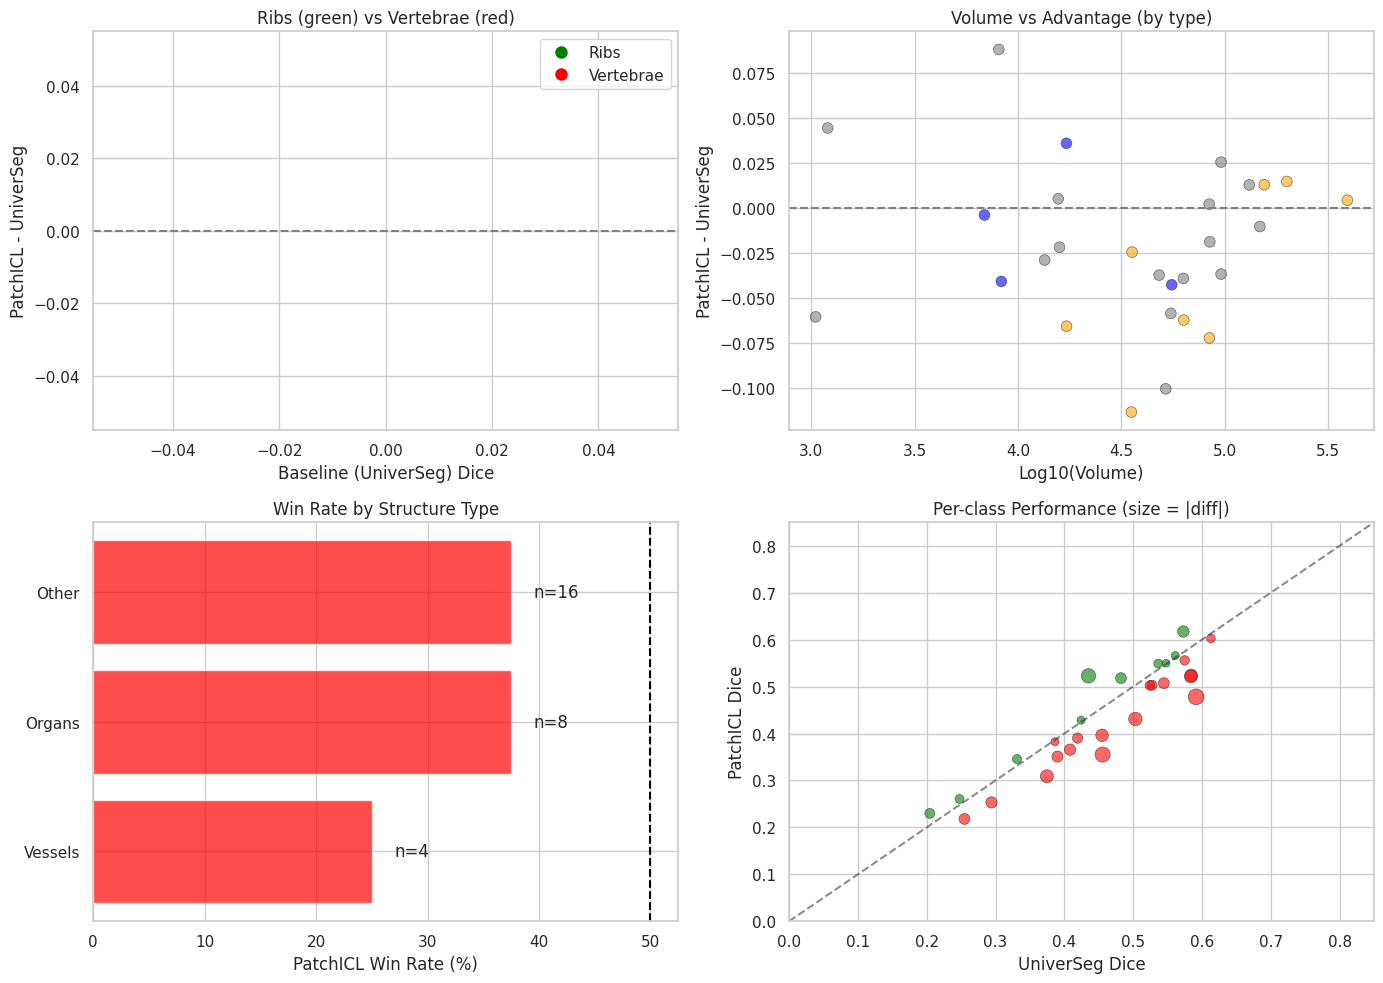

In [49]:
# ================================================================
# VISUALIZATION: Pattern summary
# ================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Ribs vs Vertebrae comparison
ax = axes[0, 0]
rib_verts = analysis_df[analysis_df['is_rib'] | analysis_df['is_vertebra']].copy()
rib_verts['type'] = rib_verts['is_rib'].map({True: 'Ribs', False: 'Vertebrae'})
colors_rv = ['green' if t == 'Ribs' else 'red' for t in rib_verts['type']]
ax.scatter(rib_verts['universeg_mean'], rib_verts['diff'], c=colors_rv, s=80, alpha=0.7, edgecolors='k')
ax.axhline(0, color='gray', linestyle='--')
ax.set_xlabel('Baseline (UniverSeg) Dice')
ax.set_ylabel('PatchICL - UniverSeg')
ax.set_title('Ribs (green) vs Vertebrae (red)')
ax.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10, label='Ribs'),
                   plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Vertebrae')])

# 2. Volume vs diff with structure type coloring
ax = axes[0, 1]
colors_type = []
for _, row in analysis_df.iterrows():
    if row['is_rib']:
        colors_type.append('green')
    elif row['is_vertebra']:
        colors_type.append('red')
    elif row['is_vessel']:
        colors_type.append('blue')
    elif row['is_organ']:
        colors_type.append('orange')
    else:
        colors_type.append('gray')
ax.scatter(analysis_df['log_volume'], analysis_df['diff'], c=colors_type, s=60, alpha=0.6, edgecolors='k', linewidth=0.5)
ax.axhline(0, color='gray', linestyle='--')
ax.set_xlabel('Log10(Volume)')
ax.set_ylabel('PatchICL - UniverSeg')
ax.set_title('Volume vs Advantage (by type)')

# 3. Win rate by structure type
ax = axes[1, 0]
type_stats = []
for stype, col in [('Ribs', 'is_rib'), ('Vertebrae', 'is_vertebra'), 
                   ('Vessels', 'is_vessel'), ('Organs', 'is_organ'), ('Other', None)]:
    if col:
        subset = analysis_df[analysis_df[col]]
    else:
        subset = analysis_df[~(analysis_df['is_rib'] | analysis_df['is_vertebra'] | 
                               analysis_df['is_vessel'] | analysis_df['is_organ'])]
    if len(subset) > 0:
        type_stats.append({
            'type': stype, 
            'win_rate': (subset['diff'] > 0).mean() * 100,
            'mean_diff': subset['diff'].mean(),
            'n': len(subset)
        })
type_df = pd.DataFrame(type_stats)
colors_bar = ['green' if d > 0 else 'red' for d in type_df['mean_diff']]
bars = ax.barh(type_df['type'], type_df['win_rate'], color=colors_bar, alpha=0.7)
ax.axvline(50, color='black', linestyle='--')
ax.set_xlabel('PatchICL Win Rate (%)')
ax.set_title('Win Rate by Structure Type')
for i, (_, row) in enumerate(type_df.iterrows()):
    ax.text(row['win_rate'] + 2, i, f"n={row['n']}", va='center')

# 4. Difficulty effect scatter
ax = axes[1, 1]
colors_diff = ['green' if d > 0 else 'red' for d in analysis_df['diff']]
sizes = 30 + 100 * (analysis_df['diff'].abs() / analysis_df['diff'].abs().max())
ax.scatter(analysis_df['universeg_mean'], analysis_df['patch_icl_mean'], 
           c=colors_diff, s=sizes, alpha=0.6, edgecolors='k', linewidth=0.5)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)  # diagonal
ax.set_xlabel('UniverSeg Dice')
ax.set_ylabel('PatchICL Dice')
ax.set_title('Per-class Performance (size = |diff|)')
ax.set_xlim(0, 0.85)
ax.set_ylim(0, 0.85)

plt.tight_layout()
plt.show()

In [50]:
from scipy.stats import wilcoxon, ttest_rel, mannwhitneyu, pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

# ================================================================
# STATISTICAL TESTS
# ================================================================
print("=" * 70)
print("STATISTICAL ANALYSIS: PatchICL vs UniverSeg")
print("=" * 70)

# 1. Overall paired comparison (same case, same label)
df_patch = df_all[df_all['Run'] == 'patch_icl'].set_index(['case_id', 'label_id'])['dice']
df_univ = df_all[df_all['Run'] == 'universeg'].set_index(['case_id', 'label_id'])['dice']
common_idx = df_patch.index.intersection(df_univ.index)

paired_patch = df_patch.loc[common_idx].values
paired_univ = df_univ.loc[common_idx].values

# Paired Wilcoxon signed-rank test (non-parametric)
stat_wilcox, p_wilcox = wilcoxon(paired_patch, paired_univ, alternative='two-sided')
# Paired t-test
stat_t, p_t = ttest_rel(paired_patch, paired_univ)

print(f"\n1. OVERALL PAIRED COMPARISON (n={len(common_idx)} paired samples)")
print("-" * 70)
print(f"   Mean Dice - PatchICL: {paired_patch.mean():.4f}, UniverSeg: {paired_univ.mean():.4f}")
print(f"   Mean difference: {(paired_patch - paired_univ).mean():.4f}")
print(f"   Paired t-test: t={stat_t:.2f}, p={p_t:.2e}")
print(f"   Wilcoxon signed-rank: W={stat_wilcox:.0f}, p={p_wilcox:.2e}")
if p_wilcox < 0.05:
    winner = "PatchICL" if (paired_patch - paired_univ).mean() > 0 else "UniverSeg"
    print(f"   → Significant difference (p<0.05): {winner} is better overall")
else:
    print(f"   → No significant difference (p={p_wilcox:.3f})")

STATISTICAL ANALYSIS: PatchICL vs UniverSeg

1. OVERALL PAIRED COMPARISON (n=657 paired samples)
----------------------------------------------------------------------
   Mean Dice - PatchICL: 0.4443, UniverSeg: 0.4705
   Mean difference: -0.0262
   Paired t-test: t=-10.30, p=1.16e-24
   Wilcoxon signed-rank: W=7922328, p=2.12e-32
   → Significant difference (p<0.05): UniverSeg is better overall


In [51]:
# Check for zero/NaN diffs                                                                                                                                                                                               
for res in [128, 256, 512]:
    sub = pivot[pivot['resolution'] == res]                                                                                                                                                                              
    if len(sub) > 0:                                                                                                                                                                                                   
        ds_stats = sub.groupby('dataset')['diff'].mean()
        print(f"\n{res}x{res}:")
        print(f"  NaN diffs: {ds_stats.isna().sum()}")
        print(f"  Zero diffs: {(ds_stats == 0).sum()}")
        print(f"  Near-zero (|diff| < 0.01): {(ds_stats.abs() < 0.01).sum()}")
        print(f"  Datasets: {ds_stats.sort_values().to_dict()}")



KeyError: 'resolution'

In [ ]:
# Get category-level statistics for the MRI results table
cat_stats = df_all.groupby(['Run', 'category'], observed=False)['dice'].agg(['mean', 'std']).reset_index()
cat_pivot = cat_stats.pivot(index='category', columns='Run', values=['mean', 'std'])

print("=== TABLE DATA FOR REPORT (TotalSeg MRI) ===\n")
print(f"{'Category':<30} {'PatchICL':>20} {'UniverSeg':>20}")
print("-" * 75)

for cat in cat_pivot.index:
    pi_mean = cat_pivot.loc[cat, ('mean', 'patch_icl')]
    pi_std = cat_pivot.loc[cat, ('std', 'patch_icl')]
    us_mean = cat_pivot.loc[cat, ('mean', 'universeg')]
    us_std = cat_pivot.loc[cat, ('std', 'universeg')]
    print(f"{cat:<30} {pi_mean:.3f} ± {pi_std:.3f}      {us_mean:.3f} ± {us_std:.3f}")

# Overall
print("-" * 75)
for run in ['patch_icl', 'universeg']:
    scores = df_all[df_all['Run'] == run]['dice']
    print(f"Overall {run}: {scores.mean():.3f} ± {scores.std():.3f}")

=== TABLE DATA FOR REPORT (TotalSeg MRI) ===

Category                                   PatchICL            UniverSeg
---------------------------------------------------------------------------
Bones (Limbs/Pelvis)           0.417 ± 0.340      0.423 ± 0.350
Bones (Spine)                  0.422 ± 0.229      0.504 ± 0.243
Muscles (Trunk)                0.447 ± 0.304      0.488 ± 0.305
Organs (Abd/Pelvis)            0.436 ± 0.298      0.459 ± 0.307
Organs (Thorax/Head/Spine)     0.550 ± 0.291      0.547 ± 0.294
Vessels                        0.381 ± 0.312      0.398 ± 0.326
---------------------------------------------------------------------------
Overall patch_icl: 0.444 ± 0.300
Overall universeg: 0.473 ± 0.307


In [ ]:
# Per-class comparison
label_stats = df_all.groupby(['Run', 'label_id'], observed=False)['dice'].mean().reset_index()
pivot = label_stats.pivot(index='label_id', columns='Run', values='dice')
pivot['diff'] = pivot['patch_icl'] - pivot['universeg']

n_total = len(pivot)
n_patch_wins = (pivot['diff'] > 0).sum()

print(f"Per-class: PatchICL wins {n_patch_wins}/{n_total} classes ({100*n_patch_wins/n_total:.0f}%)")
print(f"Overall mean diff: {pivot['diff'].mean():+.3f}")

print("\n=== TOP 5 PatchICL advantage ===")
print(pivot.nlargest(5, 'diff')[['patch_icl', 'universeg', 'diff']].to_string())

print("\n=== TOP 5 UniverSeg advantage ===")
print(pivot.nsmallest(5, 'diff')[['patch_icl', 'universeg', 'diff']].to_string())

Per-class: PatchICL wins 13/46 classes (28%)
Overall mean diff: -0.029

=== TOP 5 PatchICL advantage ===
Run                 patch_icl  universeg      diff
label_id                                          
esophagus            0.523002   0.435110  0.087892
adrenal_gland_left   0.617310   0.573043  0.044267
inferior_vena_cava   0.518056   0.482271  0.035785
lung_right           0.586510   0.556572  0.029938
hip_left             0.229868   0.204520  0.025348

=== TOP 5 UniverSeg advantage ===
Run                    patch_icl  universeg      diff
label_id                                             
kidney_left             0.478132   0.591577 -0.113446
intervertebral_discs    0.374938   0.486323 -0.111385
urinary_bladder         0.556316   0.666256 -0.109940
iliopsoas_right         0.355144   0.455669 -0.100525
gluteus_minimus_right   0.293162   0.383230 -0.090068


In [ ]:
# Check all categories present
print("Categories in MRI data:")
print(df_all['category'].unique())

# Check for thigh muscles specifically
thigh_labels = df_all[df_all['label_id'].str.contains('thigh|quadriceps|sartorius', case=False)]['label_id'].unique()
print(f"\nThigh-related labels: {list(thigh_labels)}")

Categories in MRI data:
['Muscles (Trunk)' 'Bones (Spine)' 'Vessels' 'Organs (Abd/Pelvis)'
 'Bones (Limbs/Pelvis)' 'Organs (Thorax/Head/Spine)']

Thigh-related labels: []
